# Neural Network from scratch

in notebook 01 a single perceptron couldnt crack XOR. now i build a small network with one hidden layer in plain numpy, forward pass, backprop, gradient descent all by hand, and it solves XOR.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

## the pieces

input → hidden layer (tanh) → output (sigmoid). tanh bends the space, sigmoid squashes the output into a probability between 0 and 1.

In [2]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [3]:
def init_params(n_in, n_hidden, n_out, seed=0):
    rng = np.random.default_rng(seed)
    # small random weights, zero biases
    return {
        'W1': rng.normal(0, 1, (n_in, n_hidden)) * 0.5,
        'b1': np.zeros((1, n_hidden)),
        'W2': rng.normal(0, 1, (n_hidden, n_out)) * 0.5,
        'b2': np.zeros((1, n_out)),
    }

## forward pass

push X through: hidden = tanh(X·W1 + b1), output = sigmoid(hidden·W2 + b2).

In [4]:
def forward(X, p):
    z1 = X @ p['W1'] + p['b1']
    a1 = np.tanh(z1)              # hidden activation
    z2 = a1 @ p['W2'] + p['b2']
    a2 = sigmoid(z2)             # output, a probability
    return {'a1': a1, 'a2': a2}

## loss

binary cross entropy, how far the predicted probability is from the real label.

In [5]:
def compute_loss(a2, y):
    eps = 1e-9
    return -np.mean(y * np.log(a2 + eps) + (1 - y) * np.log(1 - a2 + eps))

## backprop

the chain rule, push the error backwards to get each weights gradient, then gradient descent nudges them down the loss.

In [6]:
def backward(X, y, p, cache):
    m = len(y)
    a1, a2 = cache['a1'], cache['a2']

    dz2 = a2 - y                      # output error
    dW2 = a1.T @ dz2 / m
    db2 = np.mean(dz2, axis=0, keepdims=True)

    dz1 = (dz2 @ p['W2'].T) * (1 - a1 ** 2)   # tanh derivative
    dW1 = X.T @ dz1 / m
    db1 = np.mean(dz1, axis=0, keepdims=True)

    return {'W1': dW1, 'b1': db1, 'W2': dW2, 'b2': db2}

In [18]:
def train(X, y, n_hidden=8, lr=0.5, epochs=5000, seed=0):
    p = init_params(X.shape[1], n_hidden, 1, seed)
    losses = []
    for e in range(epochs):
        cache = forward(X, p)
        grads = backward(X, y, p, cache)
        for k in p:
            p[k] -= lr * grads[k]            # gradient descent step
        if e % 100 == 0:
            losses.append(compute_loss(cache['a2'], y))
    return p, losses

In [8]:
def predict(X, p):
    return (forward(X, p)['a2'] >= 0.5).astype(int)

## XOR, the rematch

the exact one the perceptron failed on. lets train our net on it.

In [9]:
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
y = np.array([[0], [1], [1], [0]], dtype=float)

p, losses = train(X, y, n_hidden=8, lr=0.5, epochs=5000)
print("accuracy:", (predict(X, p) == y).mean())
print("pred  :", predict(X, p).ravel())
print("actual:", y.ravel().astype(int))

accuracy: 1.0
pred  : [0 1 1 0]
actual: [0 1 1 0]


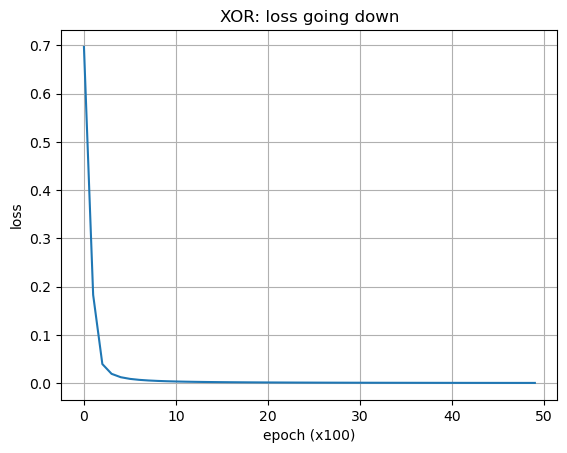

In [10]:
plt.plot(losses)
plt.title("XOR: loss going down")
plt.xlabel("epoch (x100)"); plt.ylabel("loss"); plt.grid(True); plt.show()

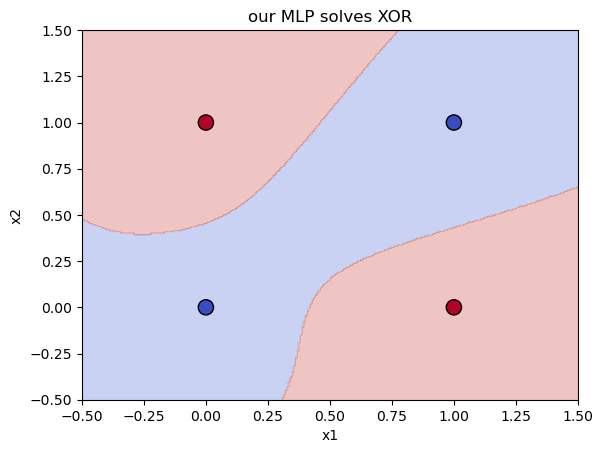

In [11]:
def plot_boundary(p, X, y, title):
    xx, yy = np.meshgrid(np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 300),
                         np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 300))
    Z = predict(np.c_[xx.ravel(), yy.ravel()], p).reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    plt.scatter(X[:, 0], X[:, 1], c=y.ravel(), cmap='coolwarm', s=120, edgecolors='k')
    plt.title(title); plt.xlabel("x1"); plt.ylabel("x2"); plt.show()

plot_boundary(p, X, y, "our MLP solves XOR")

## two moons

XOR is tiny. moons is a proper non-linear dataset, two interleaving crescents that no straight line can split.

In [12]:
Xm, ym = make_moons(n_samples=300, noise=0.2, random_state=42)
ym = ym.reshape(-1, 1).astype(float)
Xtr, Xte, ytr, yte = train_test_split(Xm, ym, test_size=0.3, random_state=42)

p2, losses2 = train(Xtr, ytr, n_hidden=8, lr=0.5, epochs=5000)
print("train acc:", round((predict(Xtr, p2) == ytr).mean(), 3))
print("test acc :", round((predict(Xte, p2) == yte).mean(), 3))

train acc: 0.957
test acc : 0.978


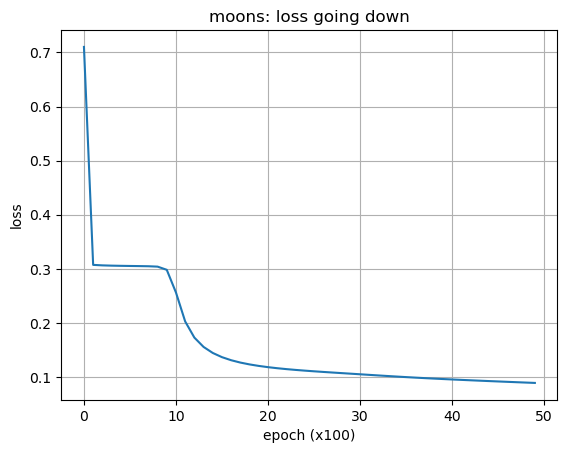

In [13]:
plt.plot(losses2)
plt.title("moons: loss going down")
plt.xlabel("epoch (x100)"); plt.ylabel("loss"); plt.grid(True); plt.show()

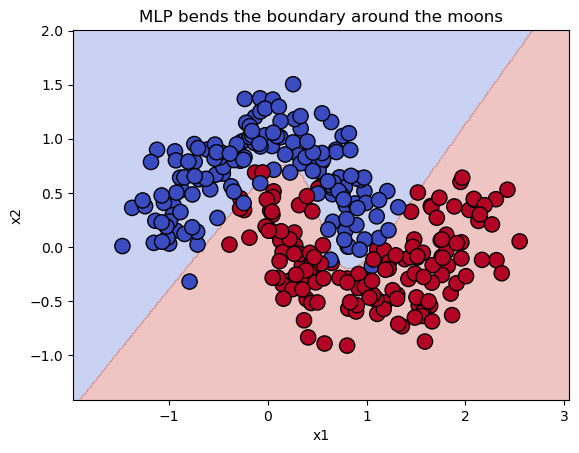

In [14]:
plot_boundary(p2, Xm, ym, "MLP bends the boundary around the moons")

so one hidden layer plus backprop bends the boundary and cracks problems a single line never could. next i run this on a real dataset and check it against sklearn.